Здесь я экспериментирую с feature extraction. Я и тренирую здесь простые модели, но только для оценки полезности признаков, разработкой собственно модели можно будет заняться только позднее.

In [358]:
import polars as pl
dataset = pl.read_csv(
    '../data/processed/dataset_clean_onehot_label.csv'
)


In [359]:
SEED = 42


In [360]:
dataset.columns


['StimSite',
 'Stimulus',
 'RT_start',
 'Response_annot',
 'Response_transcription_annot',
 'speech arrest',
 'аномия',
 'дизартрия',
 'задержка',
 'нет',
 'поиск слова',
 'семантическая парафазия',
 'фонетическая парафазия',
 'Error_type_annot',
 'error_type_label']

In [361]:
dataset_0 = dataset[[
    'Stimulus',
    'RT_start',
    'Response_annot',
    'error_type_label'
    ]]\

dataset_0[['RT_start']] = dataset_0[['RT_start']]\
                          .fill_null(strategy='zero')

dataset_0[['Response_annot']] = dataset_0[['Response_annot']]\
                        .fill_null('')

# мы не хотим получать подсказки в виде #нрзб# и прочих особенностей
# разметки, т. к. они не всегда могут быть доступны
dataset_0 = dataset_0.with_columns(
    pl.col('Response_annot').str.replace_all(r'[^а-яё ]', '').str.to_lowercase()
)


Различные способы заполнения слабо влияют на метрики по результатам части 1, но при заполнении нулями метрики для классов, которые ожидаемо выявляются по признаку `RT_start`, оказываются немного выше.

# 1. Длина ответа относительно длины стимула

In [362]:
dataset_1 = dataset_0.with_columns(
                            (pl.col('Response_annot').str.len_chars() /
                            pl.col('Stimulus').str.len_chars())\
                            .fill_null(0)\
                            .alias('relative_length')
                            )


In [363]:
from json import load

error_type_ids_file = open('../data/processed/error_type_ids.json',
                        'r', -1, 'utf-8')
error_type_ids = load(error_type_ids_file)
print(*error_type_ids.items(), sep='\n')
error_type_ids_to_names: list[str] = [''] * 8
for k, v in error_type_ids.items():
    error_type_ids_to_names[v] = k


('speech arrest', 1)
('аномия', 2)
('дизартрия', 3)
('задержка', 4)
('нет', 0)
('поиск слова', 5)
('семантическая парафазия', 6)
('фонетическая парафазия', 7)


In [364]:
X = dataset_1[['relative_length', 'RT_start']]
y = dataset_1['error_type_label']




In [365]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, confusion_matrix
from matplotlib.pyplot import imshow, ylabel, xlabel, yticks, xticks
import numpy as np

def evaluate(X, y, pipeline: Pipeline = Pipeline([
            ('classifier', RandomForestClassifier(random_state=SEED))])
        ):
    # relative_length и RT_start — разного масштаба, для
    # линейных моделей здесь был бы скейлер
    k = 5
    stratified_k_fold = StratifiedKFold(n_splits = k, # test 20%
                                        shuffle = True,
                                        random_state=SEED)

    f1s = np.zeros((k, 8))
    confusion_matrices = np.zeros((k, 8, 8))

    for i, (train_mask, test_mask) in\
                    enumerate(stratified_k_fold.split(X, y)):
        X_train, X_test = X[train_mask], X[test_mask]
        y_train, y_test = y[train_mask], y[test_mask]
        pipeline.fit(X_train, y_train)
        predictions = pipeline.predict(X_test)
        f1s[i] = f1_score(y_test, predictions, average=None)
        confusion_matrices[i] = confusion_matrix(y_test, predictions)

    np.set_printoptions(suppress=True)

    print(*((name, f1.round(4).item())
            for name, f1
            in zip(error_type_ids_to_names, f1s.mean(axis=0))), sep='\n')
    
    confusion_matrix_mean = confusion_matrices.mean(axis = 0).round(2)
    confusion_matrix_normalized = confusion_matrix_mean / \
                    confusion_matrix_mean.sum(axis=1, keepdims=True)
    imshow(confusion_matrix_normalized)
    ylabel('Истина')
    xlabel('Предсказание')
    yticks(range(8), error_type_ids_to_names)
    xticks(range(8), error_type_ids_to_names, rotation=90)




('нет', 0.9484)
('speech arrest', 0.0)
('аномия', 0.7704)
('дизартрия', 0.0946)
('задержка', 0.4493)
('поиск слова', 0.2461)
('семантическая парафазия', 0.1268)
('фонетическая парафазия', 0.0375)


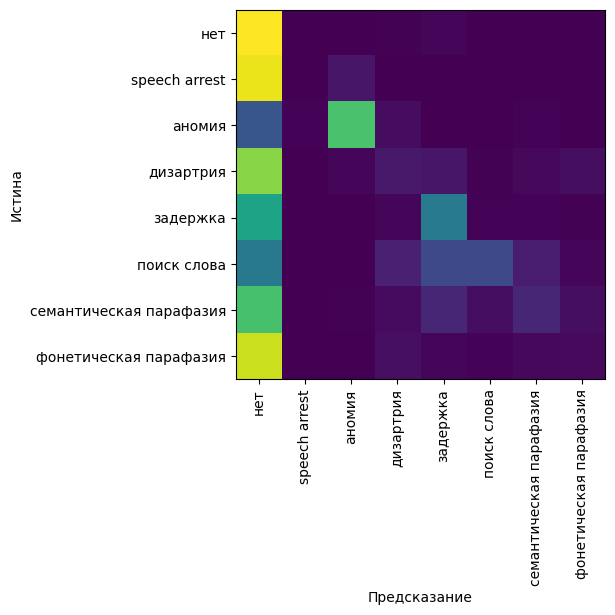

In [366]:
evaluate(X, y)


Модель лишь по этим двум признакам уже хорошо определяет случаи, когда ошибки нет. Также по относительной длине ответа и по задержке она неплохо определяет аномию и задержку, хотя последнюю при наличии RT_start должно быть проще определять. Как ни странно, модель не справляется со случаями speech arrest: хотя у них есть явный признак в виде нулевой длины ответа. Это может быть связано с их малым количеством в датасете и с ошибками или особенностями в разметке этих немногих примеров:

In [367]:
speech_arrest_points = dataset_1.filter(pl.col('error_type_label') == 1)
print(len(speech_arrest_points))
display(speech_arrest_points.filter(pl.col('relative_length') != 0))


35


Stimulus,RT_start,Response_annot,error_type_label,relative_length
str,i64,str,i64,f64
"""горох""",0,"""нрзб""",1,0.8
"""сушить""",0,"""сушит""",1,0.833333
"""тереть""",0,"""трёт""",1,0.666667
"""черепаха""",0,"""это черепаха""",1,1.5


Видимо, некоторые типы ошибок могут быть сопряжены с характерными символами в размеченном ответе. Впрочем, на это не следует полагаться, так как решение, делающее так, не будет работать на датасете с другими стандартами разметки (например, на полученном автоматической транскрипцией).

# 2. Расстояние Левенштейна между стимулом и ответом

## Простейший случай
Сначала посмотрим на полезность доли вставок, удалений и замен. Доли, потому что стимулы могут быть разной длины, и для них будет в разной степени критично одно и то же абсолютное количество замен.

In [368]:
from rapidfuzz.distance import Levenshtein

def indelrep(stimulus, response) -> tuple[int, int, int]:
    edit_operations = Levenshtein.editops(stimulus, response)
    operation_counts = [0] * 3
    operation_ids = dict(zip(['insert', 'delete', 'replace'], range(3)))
    for tag, _, _ in edit_operations:
        operation_counts[operation_ids[tag]] += 1
    return tuple(count / len(stimulus) for count in operation_counts)

print(indelrep('роман', 'роамн'))


(0.2, 0.2, 0.0)


In [369]:
dataset_2 = dataset_1

In [370]:
dataset_2 = dataset_2.with_columns(
    pl.struct(['Stimulus', 'Response_annot'])
    .map_elements(
        lambda s: indelrep(s['Stimulus'], s['Response_annot']), 
        return_dtype=pl.Struct([
            pl.Field('insertions', pl.Float64),
            pl.Field('deletions', pl.Float64),
            pl.Field('replacements', pl.Float64)
        ])
    )
    .alias('edit_distance_components')
).unnest('edit_distance_components')


In [371]:
dataset_2.sample(10)


Stimulus,RT_start,Response_annot,error_type_label,relative_length,insertions,deletions,replacements
str,i64,str,i64,f64,f64,f64,f64
"""цепь""",1140,"""это цепь""",4,2.0,1.0,0.0,0.0
"""кроссворд""",651,"""это кроссворд""",0,1.444444,0.444444,0.0,0.0
"""чемодан""",658,"""это чемодан""",0,1.571429,0.571429,0.0,0.0
"""клоун""",903,"""это клоун""",0,1.8,0.8,0.0,0.0
"""ракета""",632,"""это ракета""",0,1.666667,0.666667,0.0,0.0
"""загорать""",1084,"""загорает""",0,1.0,0.125,0.125,0.0
"""цепь""",850,"""это цепь""",0,2.0,1.0,0.0,0.0
"""звонить""",1159,"""звонит""",0,0.857143,0.0,0.142857,0.0
"""нюхать""",897,"""нюхает""",0,1.0,0.166667,0.166667,0.0


('нет', 0.9532)
('speech arrest', 0.0)
('аномия', 0.7535)
('дизартрия', 0.126)
('задержка', 0.4741)
('поиск слова', 0.3379)
('семантическая парафазия', 0.3147)
('фонетическая парафазия', 0.2797)


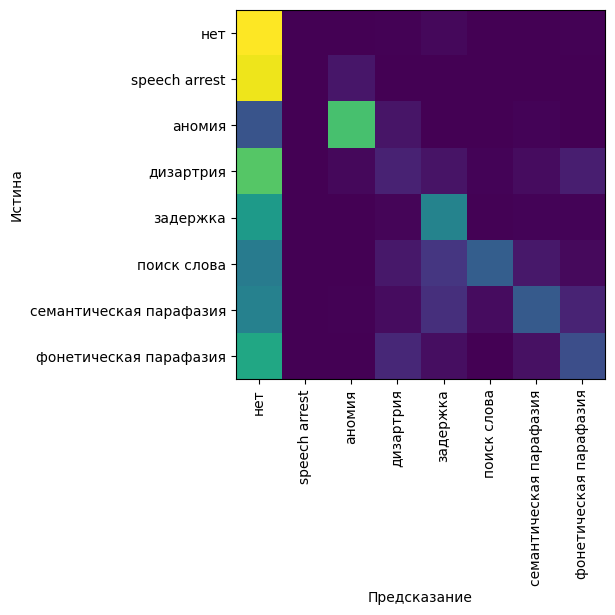

In [372]:
X = dataset_2[['RT_start', 'relative_length',
               'insertions', 'deletions', 'replacements']]
y = dataset_2['error_type_label']
evaluate(X, y)


Как и предполагалось, стало лучше с нахождением фонетической парафазии и, в меньшей степени, дизартрии и задержки, но всё ещё не так хорошо. Без моего намерения, хотя и объяснимо, поднялась метрика для семантической парафазии и поиска слова.



## Отдельные замены

Найдём самые частотные замены, оставим только их количество для каждого поинта, натренируем модель и посмотрим, как она справится. Тут возникнет две проблемы:
 + Матрица признаков будет разреженной; нужно будет или поднять порог частотности, или выбрать классификатор, который хорошо с таким работает.
 + Нужно писать свой трансформер для sklearn, потому что считать частотность по-хорошему надо каждый раз на тренировочной выборке, а не на датасете целиком, чтобы избежать утечки распределения. Это будет полезно позже, когда все операции над датасетом надо будет проводить в пайплайне.

In [373]:
import re

def get_replacement_pairs(**kwargs):
    stimulus = kwargs['Stimulus']
    response = kwargs['Response_annot']
    return [(stimulus[i], response[j])
            for tag, i, j in Levenshtein.editops(stimulus, 
                                            response)
            if tag == 'replace']


In [374]:
get_replacement_pairs(**{'Stimulus': 'штегрусым',
                       'Response_annot': 'это штеграсым'})


[('у', 'а')]

In [375]:
from numpy import ndarray
from sklearn.base import BaseEstimator, TransformerMixin
from collections import Counter

class ReplacementCounter(BaseEstimator, TransformerMixin):
    def __init__(self, max_features=100):
        self.max_features = max_features

    def _counts(self, X: pl.DataFrame):
        if not ('Stimulus' in X.columns or\
                'Response_annot' in X.columns):
            raise TypeError('Нет ожидаемых колонок')
        new_rows = []
        for row in X\
            .with_row_index('id')\
            .to_dicts():
            pairs = Counter()
            pairs.update([f'replacements_{l1}_{l2}' \
                        for l1, l2 in get_replacement_pairs(**row)])
            row.update(pairs.items())
            new_rows.append(row)
        return pl.from_dicts(new_rows)
    
    def fit(self, X: pl.DataFrame, y = None):
        columns_before = X.columns
        X = self._counts(X[['Stimulus', 'Response_annot']])
        self.top_columns = \
            X.select(pl.all()\
                .exclude(pl.String)\
                .sum()
            )\
            .unpivot()\
            .sort('value', descending=True)\
            .head(self.max_features + 1)
        # print(self.top_columns)
        self.feature_columns = self.top_columns\
            .get_column('variable')\
            .to_list()
        self.columns_to_leave = columns_before + self.feature_columns
        return self
    def transform(self, X):
        counts = self._counts(X)
        counts = counts.with_columns(
                [pl.lit(None, dtype=pl.Int64).alias(c) 
                for c in self.feature_columns
                if c not in counts.columns]
            )\
            .select(self.feature_columns)
        # print(counts)
        return X.with_row_index('id')\
            .join(counts, on='id', how='left', coalesce=True)\
            .fill_null(0)\
            .drop(['id', 'Response_annot', 'Stimulus'])


In [376]:
replacement_counter = ReplacementCounter()
replacement_counter.fit(dataset_2)
replacement_counter.transform(dataset_2[:20])


RT_start,error_type_label,relative_length,insertions,deletions,replacements,replacements_а_е,replacements_р_т,replacements_е_ё,replacements_к_т,replacements_к_н,replacements_е_,replacements_и_ы,replacements_р_о,replacements_ю_а,replacements_б_ш,replacements_л_т,replacements_о_е,replacements_к_б,replacements_я_о,replacements_г_,replacements_ц_о,replacements_ш_а,replacements_ы_,replacements_у_ж,replacements_в_о,replacements_к_ц,replacements_а_,replacements_б_в,replacements_ц_т,replacements_л_р,replacements_п_о,replacements_т_р,replacements_и_,replacements_а_б,replacements_б_с,replacements_к_а,replacements_и_р,replacements_у_к,replacements_о_б,replacements_е_р,replacements_а_з,replacements_д_н,replacements_ж_р,replacements_т_н,replacements_в_п,replacements_н_з,replacements_ь_е,replacements_т_з
i64,i64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
576,0,1.5,0.5,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
521,0,1.571429,0.571429,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
467,0,1.8,0.8,0.0,1.0,0,1,0,0,1,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
509,0,1.8,0.8,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
530,0,1.571429,0.571429,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
534,0,1.571429,0.571429,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
613,0,1.571429,0.571429,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
534,0,1.571429,0.571429,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


('нет', 0.9542)
('speech arrest', 0.0)
('аномия', 0.7835)
('дизартрия', 0.1177)
('задержка', 0.4732)
('поиск слова', 0.3383)
('семантическая парафазия', 0.3298)
('фонетическая парафазия', 0.3873)


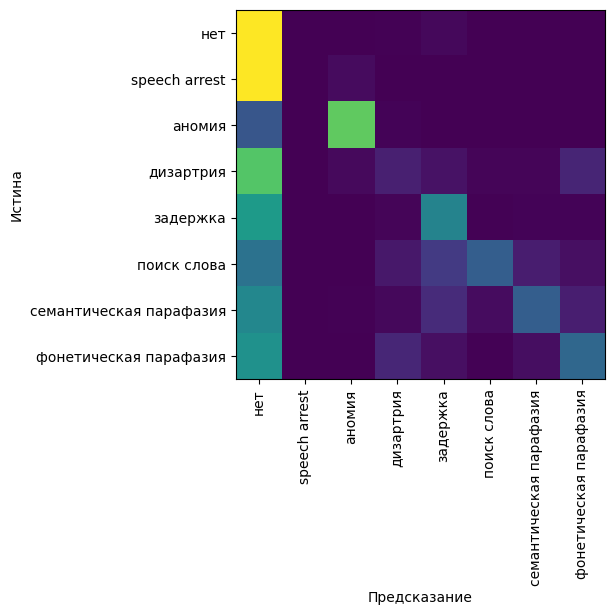

In [377]:
new_pipeline = Pipeline([
        ('counter', ReplacementCounter(max_features=99999)),
        ('classifier', RandomForestClassifier())
])

X = dataset_2[['Stimulus', 'Response_annot',
               'RT_start', 'relative_length',
               'insertions', 'deletions', 'replacements']]
y = dataset_2['error_type_label']

evaluate(X, y, new_pipeline)
